### CNNs applied to time series

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.layers import GlobalMaxPooling1D
%run plot.py

I0000 00:00:1773843553.815518  582198 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773843553.815800  582198 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773843553.855088  582198 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773843554.925285  582198 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

### Read data

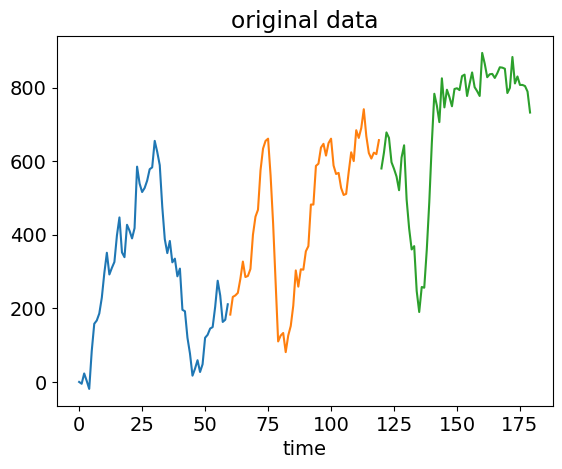

data:  10000


In [2]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

### Split train-validation and rescale

(8000, 60)
N_train= 8000   N_val= 2000   L= 60   n_class= 3
std_train average and mean: 588.25397835931 44.84287073276593 201.46657645528722
std_val average and mean: 569.9090424503428 55.06717110341998 201.92178219610327


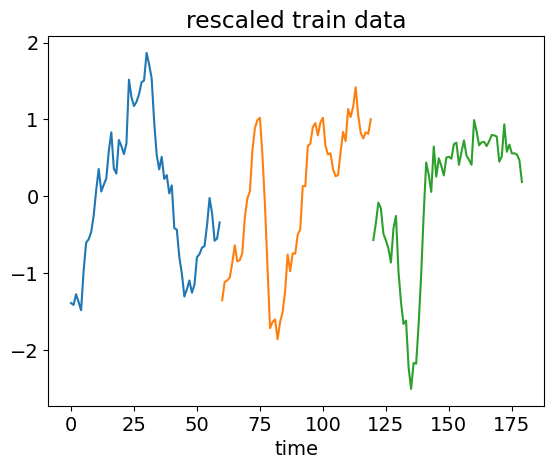

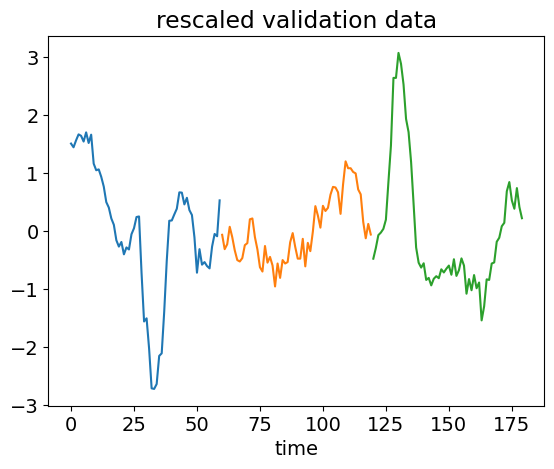

In [3]:
# split into training and validation sets
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

 
#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
    #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
     #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
for i in range(N_val):
    #x_val[i] = (x_val[i]-xm_val[i])/ std_val[i]
    #x_val[i] = (x_val[i]-xm_val[i])/ 400
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
#

    
Show_data(x_train,L,"rescaled train data")
Show_data(x_val,L,"rescaled validation data")

#x_train=x_train.astype("float32")
#y_train=y_train.astype("float32")
#x_val=x_val.astype("float32")
#y_val=y_val.astype("float32")

# Keras wants an additional dimension with a 1 at the end
x_train = x_train.reshape(x_train.shape[0], L, 1)
x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 1) # number of features, number of channels (1 for 1D data)

## Convolutional NN

In [4]:
# ...LESSON ...
# reproducibility
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

## from keras import regularizers, initializers

reg = tf.keras.regularizers.l2(0.2) ## raised to 0.2 the regularization strenghts
# a high regularization (high penalty) prevents from overfittin in noise scenarios as in this case
# in fact it prevents the model to memorize noise. (Force the model to keep low weights)
#reg = regularizers.l1(0.1)
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
#NCONV = 1 #swtich between 1 and 2 CNNs (there are 2 models: first case 2 conv layers, second we have just 1 conv layer)
NF = 6 #number of filters, will slide across the 60 time step to see
# if there are patterns. The kernel-size is the number od points the filter
# sees each time to decide if a pattern is present.
#each filter search for a different pattern (ie: sharp rise, smooth plateau ecc..)

# challenge: at most 600 tunable parameters
model = Sequential()
# 

    # -----2-----
model.add(Conv1D(filters=NF, kernel_size= 3, 
                kernel_initializer=ini, 
                kernel_regularizer=reg,
                activation='relu', 
                input_shape=input_shape)) 
    #the output of a convolution layer is a feature map: the filter has its own weights
    # it makes a dot product with each data it sees and sum the products.
    # when the filter recognize the data we have a large value, otherwise we have a 
    # value near zero (for activation = Relu any negative output is turned to zero)
    #model.add(MaxPooling1D(3))
    #model.add(AveragePooling1D(5)) # takes groups of 5 points and replace them with their average
    # pooling is usefull to smooth the noise.
model.add(Conv1D(filters=8, kernel_size=9, 
                activation='relu'))
model.add(Conv1D(filters=4, kernel_size=3, activation='relu'))
model.add(GlobalMaxPooling1D())
#model.add(Flatten())
    #model.add(Dense(12, activation='relu'))
    #model.add(Dropout(0.2))
model.add(Dense(n_class, activation='softmax')) # softmax for both! (to have the final probabilities)
#softmax outputs 3 numbers with sum 1 (probabilities): eg (0.05, 0.9, 0.05)= we are sure that our sample is labeled 1

#print('----- Model',NCONV,'-----')
print(model.summary())

# optimizers
# .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
# .RMSprop()
# .Nadam()
opt = tf.keras.optimizers.Adam()

# compile the model
# categorical_crossentropy, 3 output nodes
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])

# 60 parameters after first conv layer because

/home/elena_niero/anaconda3/envs/nn_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773843566.758526  582198 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 6)          │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 8)          │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 48, 4)          │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 4)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 579 (2.26 KB)

 Trainable params: 579 (2.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
model.layers

[<Conv1D name=conv1d, built=True>,
 <Conv1D name=conv1d_1, built=True>,
 <Conv1D name=conv1d_2, built=True>,
 <GlobalMaxPooling1D name=global_max_pooling1d, built=True>,
 <Dense name=dense, built=True>]

(3, 8, 4)
(4, 8, 3)


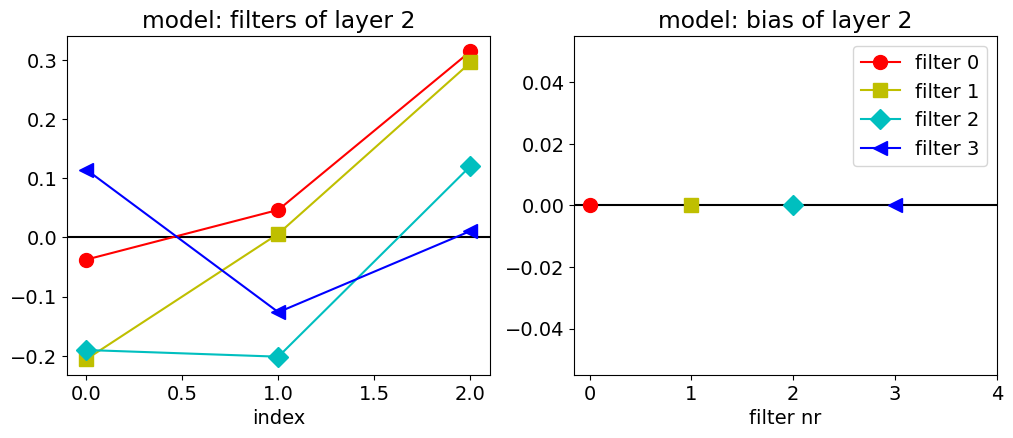

In [7]:
# plots weights on each layer, regards model 1 with 2 layers
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights, in the plot are the shapes
    # our filters are looking for
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias, decide how strong a pattern 
    # should be before the model recognize it
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()
    
#Show_weights(model,0)
Show_weights(model, 2)



# we expect that with the training the plot becomes smoother (for weights) and different from zero (for bias)
# In fact, after training each plot of weights will take the shape of the pattern
# it wants to recognize. While for the biases, when a filter learns to recognize a peak,
# its bias will become negative; in this way it will only signal the next layer if the 
# peak i found is strong enough to overcome this negative threshold. This help the model to ignore
# the smaller jumps (DX = 50) and to react only to the big ones (A=500).
# (11 = # weights, 1 = # channel, 5 = # filters)

In [8]:
# ...LESSON ...
# Hyper-parameters
# with small minibatch it does not converge!! 
BATCH_SIZE = 200
EPOCHS = 150

#print('----- Model ',NCONV,'-----\nFITTING....')
fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=2, shuffle=True) 

Epoch 1/150
40/40 - 1s - 21ms/step - accuracy: 0.4291 - loss: 1.0874 - val_accuracy: 0.4000 - val_loss: 1.0660
Epoch 2/150
40/40 - 0s - 3ms/step - accuracy: 0.5459 - loss: 1.0112 - val_accuracy: 0.6030 - val_loss: 0.9367
Epoch 3/150
40/40 - 0s - 3ms/step - accuracy: 0.7013 - loss: 0.8269 - val_accuracy: 0.7805 - val_loss: 0.7379
Epoch 4/150
40/40 - 0s - 3ms/step - accuracy: 0.8246 - loss: 0.6572 - val_accuracy: 0.8455 - val_loss: 0.6143
Epoch 5/150
40/40 - 0s - 3ms/step - accuracy: 0.8589 - loss: 0.5598 - val_accuracy: 0.8660 - val_loss: 0.5464
Epoch 6/150
40/40 - 0s - 4ms/step - accuracy: 0.8695 - loss: 0.5030 - val_accuracy: 0.8670 - val_loss: 0.5038
Epoch 7/150
40/40 - 0s - 4ms/step - accuracy: 0.8764 - loss: 0.4652 - val_accuracy: 0.8715 - val_loss: 0.4721
Epoch 8/150
40/40 - 0s - 4ms/step - accuracy: 0.8849 - loss: 0.4355 - val_accuracy: 0.8805 - val_loss: 0.4439
Epoch 9/150
40/40 - 0s - 4ms/step - accuracy: 0.8903 - loss: 0.4083 - val_accuracy: 0.8885 - val_loss: 0.4171
Epoch 10/

Validation accuracy =  0.9890000224113464


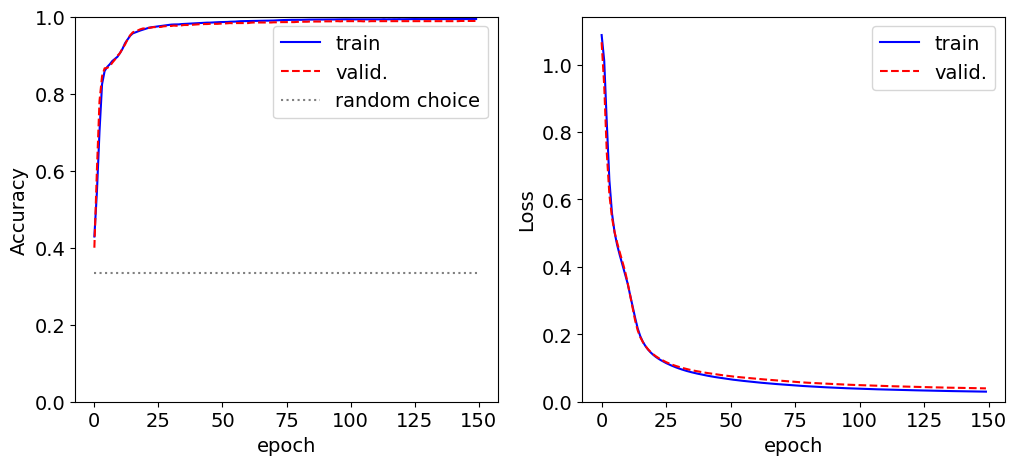

(3, 8, 4)
(4, 8, 3)


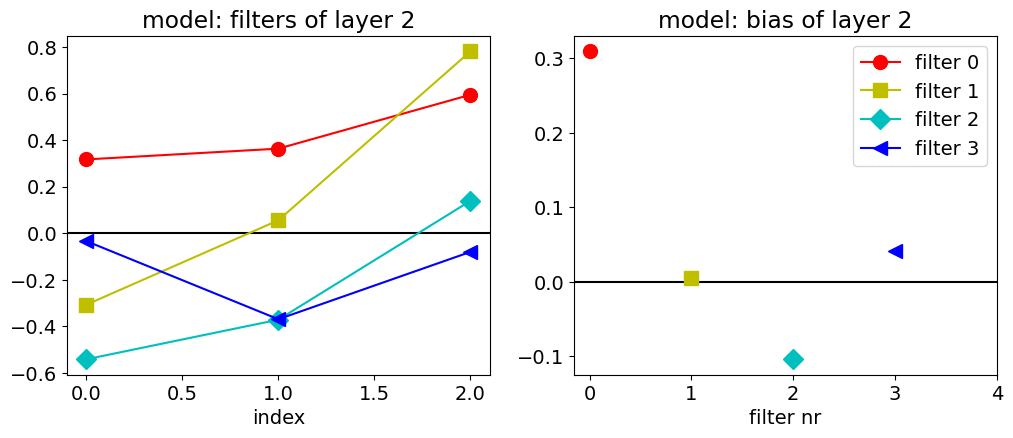

In [10]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()
print("Validation accuracy = ", fit.history['val_accuracy'][-1])
Show_history(fit)
#Show_weights(model,0)
Show_weights(model,2)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


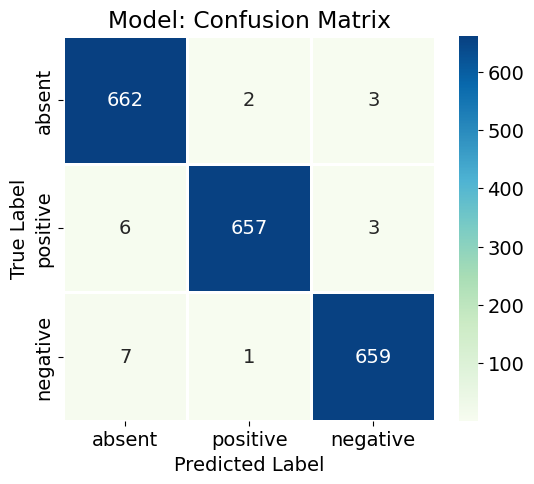

In [11]:
# confusion table: compare true labels with predicted ones
import pandas as pd
from scipy import stats

import seaborn 
from sklearn import metrics

from sklearn.metrics import classification_report
from sklearn import preprocessing

LABELS = ["absent","positive","negative"] # from labels y 
cmap="GnBu"

def show_confusion_matrix(validations, predictions, label="Model"):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 5))
    seaborn.heatmap(matrix,
                xticklabels=LABELS,
                yticklabels=LABELS,
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=1,
                cmap=cmap)
    plt.title(label+': Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

y_pred_val = model.predict(x_val)
#y_pred_val2 = model2.predict(x_val)
# Take the class with the highest probability from the val predictions
max_y_pred_val = np.argmax(y_pred_val, axis=1)
max_y_val = np.argmax(y_val, axis=1)
#max_y_pred_val2 = np.argmax(y_pred_val2, axis=1)

show_confusion_matrix(max_y_val, max_y_pred_val)
#show_confusion_matrix(max_y_val, max_y_pred_val2, label="Model 2")

#print(classification_report(max_y_val, max_y_pred_val))